In [1]:
import matplotlib.pyplot as plt
import scipp as sc
from trex.instrument import Instrument
import scipp.constants as const
from scippneutron.tof import chopper_cascade

T_OFFSET = sc.scalar(1.7, unit="ms")
central_wavelength = sc.scalar(2.5, unit="Å")
rrm: int = 8  # repetition rate multiplication factor
mode = "High Flux"  # Chopper mode


trex = Instrument(wavelength=central_wavelength, rrm=rrm, mode=mode, t_offset=T_OFFSET)
res = trex.model.run()

# Squeeze the pulse dimension since we only have one pulse
events_at_sample = res["Monitor at Sample"].data.squeeze()
# Remove the events that don't make it to the detector
events_at_sample = events_at_sample[~events_at_sample.masks["blocked_by_others"]]

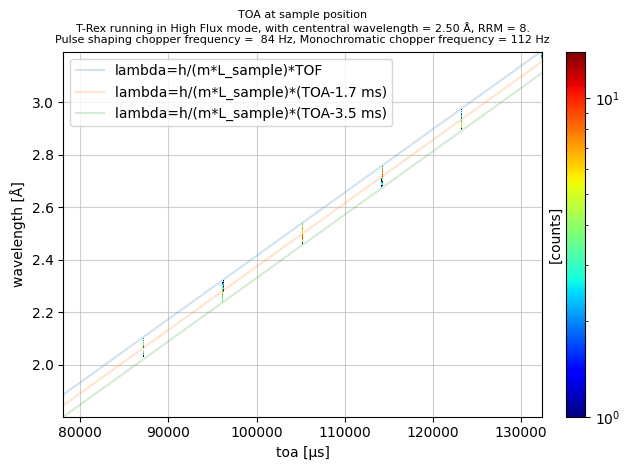

In [2]:
fig, ax = plt.subplots()
# tof_sample = events_at_sample.hist(wavelength=200, tof=500).plot(norm='log', ax=ax)
toa_sample = events_at_sample.hist(wavelength=800, toa=1500).plot(
    norm="log", cbar=True, ax=ax, cmap="jet"
)
ax.set_title("TOA at sample position\n" + str(trex), fontsize=8)
# TOF line
line_tof = sc.linspace("tof", 70, 140, 100, unit="ms").to(unit="us")
line_wavelength_tof = (
    const.h / const.m_n / trex.monitors["Monitor at Sample"].distance * line_tof
).to(unit="Å")
ax.plot(line_tof, line_wavelength_tof, label="lambda=h/(m*L_sample)*TOF", alpha=0.2)

# # TOA line
line_toa = sc.linspace("toa", 70, 140, 100, unit="ms").to(unit="us")
line_wavelength_toa = (
    const.h
    / const.m_n
    / trex.monitors["Monitor at Sample"].distance
    * (line_toa - T_OFFSET.to(unit="us"))
).to(unit="Å")
ax.plot(
    line_toa, line_wavelength_toa, label="lambda=h/(m*L_sample)*(TOA-1.7 ms)", alpha=0.2
)

line_wavelength_toa = (
    const.h
    / const.m_n
    / trex.monitors["Monitor at Sample"].distance
    * (line_toa - sc.scalar(3.5, unit="ms").to(unit="us"))
).to(unit="Å")
ax.plot(
    line_toa, line_wavelength_toa, label="lambda=h/(m*L_sample)*(TOA-3.5 ms)", alpha=0.2
)

ax.legend()
ax.grid(alpha=0.6)
fig.tight_layout()

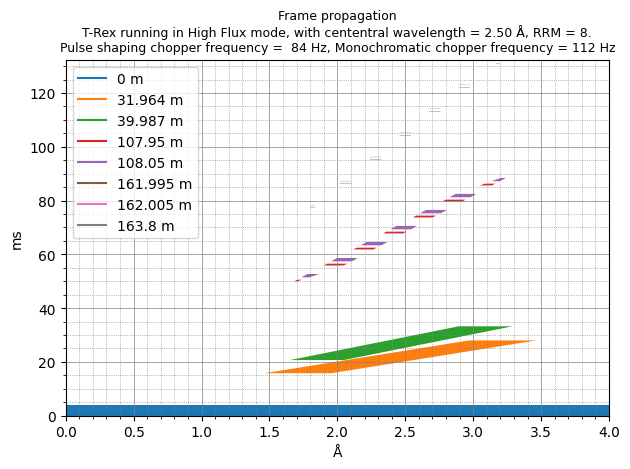

In [3]:
frames = chopper_cascade.FrameSequence.from_source_pulse(
    time_min=sc.scalar(0.0, unit="ms"),
    time_max=sc.scalar(4.0, unit="ms"),  # ESS pulse is 3 ms, but it has a tail
    wavelength_min=sc.scalar(0.0, unit="angstrom"),
    wavelength_max=sc.scalar(4.0, unit="angstrom"),
)
frames = frames.chop(trex.chopper_cascade.values())
at_sample = frames.propagate_to(trex.monitors["Monitor at Sample"].distance)

fig, ax = at_sample.draw(transpose=True)
ax.set_title("Frame propagation\n" + str(trex), fontsize=9)
ax.legend()
fig.tight_layout()

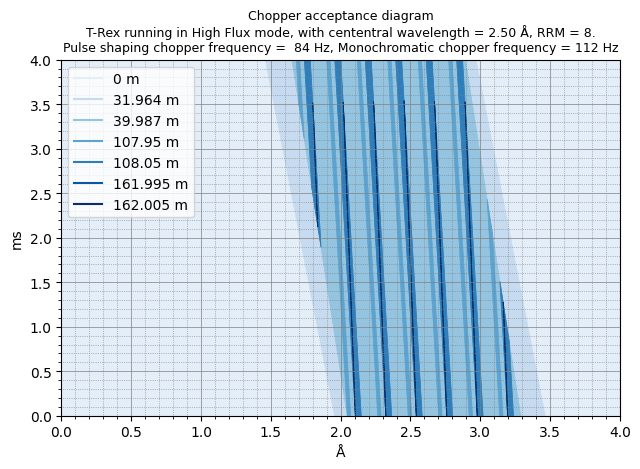

In [4]:
fig, ax = frames.acceptance_diagram()
ax.set_title("Chopper acceptance diagram\n" + str(trex), fontsize=9)
ax.legend()
fig.tight_layout()

In [20]:
from scippneutron.tof.chopper_cascade import FrameSequence
from dataclasses import dataclass


@dataclass
class SubframeVertex:
    distance: sc.Variable
    time: sc.Variable
    wavelength: sc.Variable


def acceptance_paths(
    *,
    frames: FrameSequence,
    time_unit: str = 'ms',
    wavelength_unit: str = 'angstrom',
) -> dict[str, dict]:
    frame_paths = {}
    for i, frame in enumerate(frames):
        subframe_paths = []
        for isub, subframe in enumerate(frame.subframes):
            vertex = SubframeVertex(
                distance=frame.distance,
                time = subframe.time.to(unit=time_unit, copy=False),
                wavelength = subframe.wavelength.to(unit=wavelength_unit, copy=False)
            )
            subframe_paths.append(vertex)
        frame_paths[f"{frame.distance:c}"] = subframe_paths
    return frame_paths

In [23]:
acceptance_paths(frames=frames)['162.005 m']

[SubframeVertex(distance=<scipp.Variable> ()    float64              [m]  162.005, time=<scipp.Variable> (vertex: 4)    float64             [ms]  [77.2394, 77.3443, 77.3444, 77.2394], wavelength=<scipp.Variable> (vertex: 4)    float64             [Å]  [1.8003, 1.80798, 1.83684, 1.83343]),
 SubframeVertex(distance=<scipp.Variable> ()    float64              [m]  162.005, time=<scipp.Variable> (vertex: 5)    float64             [ms]  [95.0965, 95.2025, ..., 95.1349, 95.0965], wavelength=<scipp.Variable> (vertex: 5)    float64             [Å]  [2.23593, 2.24369, ..., 2.32312, 2.3203]),
 SubframeVertex(distance=<scipp.Variable> ()    float64              [m]  162.005, time=<scipp.Variable> (vertex: 5)    float64             [ms]  [86.168, 86.2734, ..., 86.2102, 86.168], wavelength=<scipp.Variable> (vertex: 5)    float64             [Å]  [2.01812, 2.02584, ..., 2.10519, 2.10209]),
 SubframeVertex(distance=<scipp.Variable> ()    float64              [m]  162.005, time=<scipp.Variable> (verte

In [25]:
import tof

source = tof.Source(facility='ess', neutrons=1_000_000)
source

Source:
  pulses=1, neutrons per pulse=1000000
  frequency=14.0 Hz
  facility='ess'
  distance=0.0 m

In [29]:
binned = source.data.bin(birth_time=100, wavelength=100)
binned

<scipp.DataArray>
Dimensions: Sizes[birth_time:100, wavelength:100, ]
Coordinates:
* birth_time                float64            [µs]  (birth_time [bin-edge])  [12.4895, 62.229, ..., 4936.7, 4986.44]
* distance                  float64              [m]  ()  0
* wavelength                float64             [Å]  (wavelength [bin-edge])  [0.198522, 0.395519, ..., 19.7012, 19.8982]
Data:
                          DataArrayView        <no unit>  (birth_time, wavelength)  binned data: dim='_prepare_multi_dim_dense.flat_dim', content=DataArray(
          dims=(_prepare_multi_dim_dense.flat_dim: 1000000),
          data=float64[counts],
          coords={'birth_time':float64[µs], 'wavelength':float64[Å], 'speed':float64[m/s],
                  'id':int64, 'eto':float64[µs], 'toa':float64[µs]})

In [33]:
vertex = acceptance_paths(frames=frames)['162.005 m'][0]

In [34]:
vertex

SubframeVertex(distance=<scipp.Variable> ()    float64              [m]  162.005, time=<scipp.Variable> (vertex: 4)    float64             [ms]  [77.2394, 77.3443, 77.3444, 77.2394], wavelength=<scipp.Variable> (vertex: 4)    float64             [Å]  [1.8003, 1.80798, 1.83684, 1.83343])

In [37]:
from matplotlib.path import Path 
import numpy as np

vx = vertex.wavelength.values
vy = vertex.time.values
verts = np.column_stack([vx, vy])
path = Path(verts)
dims = sizes.keys()
inside = sc.array(
    dims=dims,
    values=path.contains_points(points).reshape(tuple(sizes.values())),
)
masked = da.assign_masks({str(da.masks.keys()): ~inside})

NameError: name 'sizes' is not defined

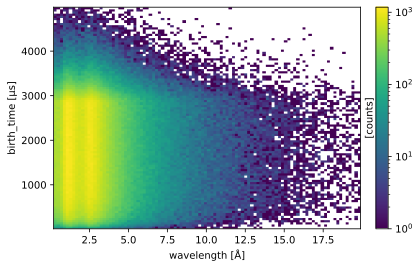

In [32]:
binned.hist().plot(norm='log')

In [6]:
# from matplotlib.path import Path
# import numpy as np

# frame=frames[-1].propagate_to(trex.source.distance)


# for subframe in frame.subframes:
#     x = subframe.time
#     y = subframe.wavelength
#     x_unit = x.unit
#     y_unit = y.unit
#     # x_max = max(x_max, x.max().value)
#     # y_max = max(y_max, y.max().value)

#     poly_path = Path(
#         np.stack((x.values, y.values), axis=1)
#     )